In [1]:
import pandas as pd
import numpy as np
from typing import Tuple

from sklearn.metrics import mean_squared_error

import pymc as pm
import xarray as xr
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.5
numpy: 2.4.3
pymc: 6.2.0
pytensor: 3.2.4
arviz: 1.3.0
arviz_plots: 1.3.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs)-> xr.DataTree:
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling

    Returns:
        xr.DataTree: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [3]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str) -> Tuple[np.array, dict]:
    """Defines an index variable starting at 0.
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values.astype("int32")
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    s = data[label].astype(str)
    vals = s.map(lookup_dict).values
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data_monthly.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,model_bat_speed,is_imputed,is_complete
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,62.0,107.51,106.923259,0.669996,168.0,NaN,73.490941,73.490941,1,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,78.0,108.94,106.961690,0.641453,193.0,NaN,73.524456,73.524456,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,73.0,105.84,106.920999,0.627866,176.0,NaN,73.491806,73.491806,1,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,76.0,106.45,106.918319,0.637789,181.0,NaN,73.488981,73.488981,1,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,79.0,107.94,106.938944,0.660242,180.0,NaN,73.506715,73.506715,1,0


In [5]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std

# define age and age squared for the model
age_values = df['age_z'].values
age_sq_values = age_values**2

n_obs = len(df)
df["player_idx"], player_lookup = define_index(df, "player_full_id")
player_idx_vals = df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())
is_imputed_data_vals = df['is_imputed'].values.astype("int32")

bat_speed_target = df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)


70.01872920073318
2.6785917750237846


<Axes: >

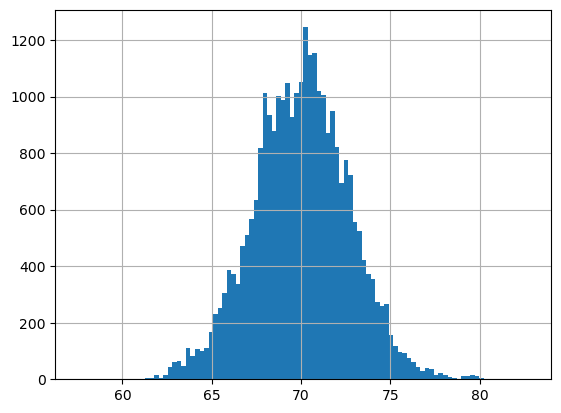

In [6]:
df['model_bat_speed'].hist(bins=100)

In [7]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

assert(np.isnan(swings_sqrt_values).sum() == 0)

80.06344835707237
59.974010044393985


In [8]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
}   

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # player random
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop, sigma=sigma_player, dims=("player",))
    
    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [9]:
trace_quad = sample(model_quad, draws = 2000, tune = 4000, target_accept = 0.99,  path='quad_model.nc')

NUTS[nutpie]: [mu_pop, sigma_player, mu_player, a, b, sigma_imputed, sigma_observed]


Output()

In [10]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma_imputed', 'sigma_observed'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.65,0.06,69.53,69.78,12693.00,6451.04,1.0,0.0,0.0
sigma_player,2.53,0.05,2.44,2.62,12108.85,6644.97,1.0,0.0,0.0
a,-0.13,0.00,-0.14,-0.12,1980.80,3031.04,1.0,0.0,0.0
b,0.03,0.01,0.02,0.04,1976.60,2937.83,1.0,0.0,0.0
sigma_imputed,4.89,0.03,4.84,4.94,10853.02,6133.70,1.0,0.0,0.0
sigma_observed,14.22,0.11,14.01,14.44,10935.00,6673.95,1.0,0.0,0.0


In [11]:
az.summary(trace_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.77,0.16,74.47,75.09,8387.67,5767.00,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],72.98,0.23,72.53,73.44,11004.80,5653.85,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.29,0.10,70.10,70.47,7922.95,5643.16,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.32,0.12,71.09,71.55,7291.78,5467.23,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.26,0.13,72.02,72.51,11364.15,5808.79,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Brett Callahan (814430)],71.05,1.97,67.22,74.89,14024.16,5797.75,1.0,0.02,0.01
mu_player[Ryan Waldschmidt (814439)],71.58,0.72,70.16,72.99,14033.29,5382.35,1.0,0.01,0.00
mu_player[Sean Keys (815873)],73.12,1.34,70.54,75.70,15396.03,6312.79,1.0,0.01,0.01
mu_player[Sung-Mun Song (823550)],71.13,0.93,69.30,72.96,15120.35,5719.43,1.0,0.01,0.01


In [12]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    curves = f_draws.reshape(-1, f_draws.shape[-1])

    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed Change (mph)")
    ax.set_ylim(-3, 1)
    ax.grid(True)
    plt.show()
    return curves_sorted

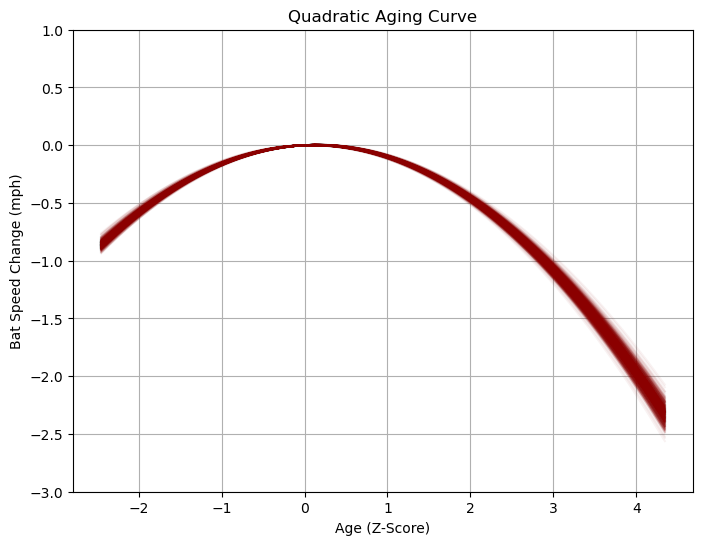

In [13]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

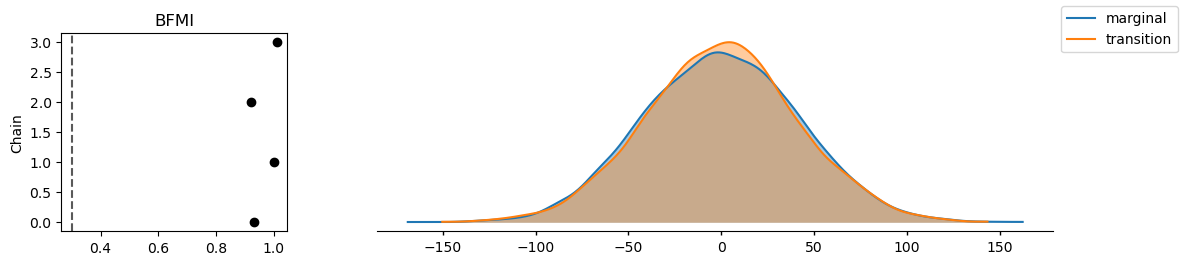

In [14]:
az.plot_energy(trace_quad)

In [15]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

Text(0.5, 0, 'Bat Speed (mph)')

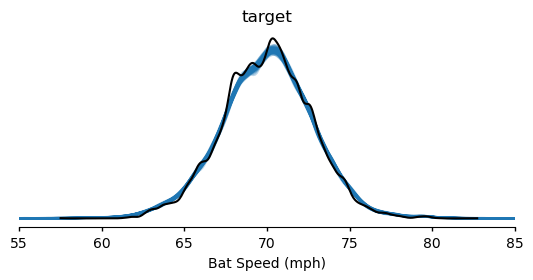

In [16]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

In [17]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

In [18]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_values), np.max(age_values)],
    lengthscale_range=[0.75, 1.25],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 9, c: 1.20


In [19]:
class QuadraticMean(pm.gp.mean.Mean):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def __call__(self, X):
        x = X[:, 0]
        return self.a * x**2 + self.b * x

In [20]:
# add position
pdf = df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,3
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,4


In [21]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # position
    sigma_position = pm.HalfNormal("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_position = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_position.prior("f", X=age_data)
    
    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [22]:
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 4000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

NUTS[nutpie]: [mu_pop, sigma_position, position_effect, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [23]:
az.summary(trace_gp_position, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed',
                                         'sigma_position','position_effect'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.23,0.08,0.12,0.43,460.32,838.72,1.01,0.00,0.00
ls,0.70,0.11,0.50,0.92,688.84,1084.05,1.01,0.00,0.00
mu_pop,69.80,0.07,69.66,69.95,2015.42,3553.45,1.00,0.00,0.00
sigma_player,2.34,0.04,2.26,2.43,8622.01,6246.40,1.00,0.00,0.00
a[0],-0.13,0.00,-0.14,-0.12,525.01,1126.42,1.00,0.00,0.00
b[0],0.03,0.01,0.02,0.05,1397.68,2454.56,1.00,0.00,0.00
sigma_imputed,4.86,0.03,4.81,4.92,6927.87,5693.89,1.00,0.00,0.00
sigma_observed,14.24,0.11,14.02,14.46,7357.10,6327.53,1.00,0.00,0.00
sigma_position,1.17,0.28,0.74,1.82,8280.11,5738.65,1.00,0.00,0.00
position_effect[DH],2.09,0.28,1.53,2.63,8242.66,6376.22,1.00,0.00,0.00


In [26]:
posit_means = trace_gp_position.posterior['position_effect'].mean(('chain','draw'))
sorted_coord = trace_gp_position.posterior['position'].sortby(posit_means)
posit_mean_sorted = trace_gp_position.sel(position=sorted_coord)

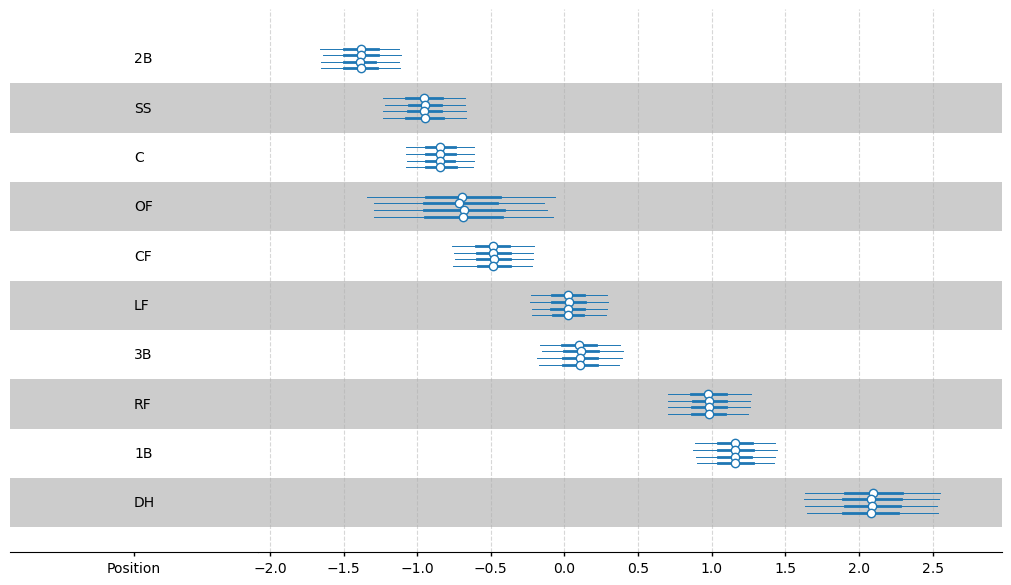

In [27]:
def rename_position(ds):
    if "position" in ds.dims:
        return ds.rename({"position": "Position"})
    return ds
posit_mean_sorted = posit_mean_sorted.map_over_datasets(rename_position)
pc = azp.plot_forest(
    posit_mean_sorted,
    var_names=['position_effect'],
    shade_label='Position',
    labels=['Position'],
    visuals={'remove_axis': True}
)
ax = plt.gca()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.show()

In [28]:
player_effects = az.summary(trace_gp_position, var_names=['mu_player'], ci_prob=0.95, round_to=2)

In [32]:
player_effects = player_effects.sort_values(['mean'])
player_effects.tail(10)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[Spencer Jones (682987)],76.18,0.71,74.78,77.58,10180.32,6237.73,1.0,0.01,0.0
mu_player[Jac Caglianone (695506)],76.55,0.39,75.78,77.33,10711.05,6129.77,1.0,0.00,0.0
mu_player[Nelson Cruz (443558)],76.77,0.06,76.64,76.89,4858.53,5476.40,1.0,0.00,0.0
mu_player[Jhonkensy Noel (678877)],76.82,0.52,75.80,77.84,11105.27,6208.57,1.0,0.00,0.0
mu_player[Vladimir Guerrero Jr. (665489)],76.85,0.07,76.70,76.99,2365.37,4497.88,1.0,0.00,0.0
mu_player[Nick Kurtz (701762)],76.95,0.37,76.23,77.68,10434.04,6394.86,1.0,0.00,0.0
mu_player[Aaron Judge (592450)],77.47,0.06,77.34,77.60,1596.17,3411.67,1.0,0.00,0.0
mu_player[Oneil Cruz (665833)],77.57,0.16,77.26,77.88,6656.44,5766.08,1.0,0.00,0.0
mu_player[Junior Caminero (691406)],78.24,0.29,77.66,78.79,10269.78,6237.17,1.0,0.00,0.0
mu_player[Giancarlo Stanton (519317)],79.54,0.07,79.42,79.67,1726.44,3144.90,1.0,0.00,0.0


In [31]:
player_effects.head(10)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[Michael Papierski (657709)],62.07,0.35,61.38,62.77,10261.03,6591.14,1.0,0.0,0.0
mu_player[Billy Hamilton (571740)],62.42,0.08,62.26,62.57,3101.00,4319.93,1.0,0.0,0.0
mu_player[Juan Graterol (492802)],62.96,0.31,62.37,63.56,10532.09,6445.30,1.0,0.0,0.0
mu_player[Jake Elmore (518653)],62.97,0.31,62.37,63.57,10913.07,6250.72,1.0,0.0,0.0
mu_player[Dee Strange-Gordon (543829)],63.11,0.08,62.96,63.27,2546.60,4125.51,1.0,0.0,0.0
mu_player[Ronald Torreyes (591720)],63.22,0.12,62.99,63.45,6161.49,6227.47,1.0,0.0,0.0
mu_player[Billy Burns (542993)],63.33,0.20,62.93,63.72,9354.33,5760.84,1.0,0.0,0.0
mu_player[Shane Robinson (453203)],63.46,0.27,62.93,64.00,9925.09,5520.80,1.0,0.0,0.0
mu_player[Terrance Gore (605253)],63.47,0.41,62.65,64.27,9422.88,6351.87,1.0,0.0,0.0
mu_player[Ben Revere (519184)],63.60,0.15,63.30,63.90,6997.13,6273.92,1.0,0.0,0.0


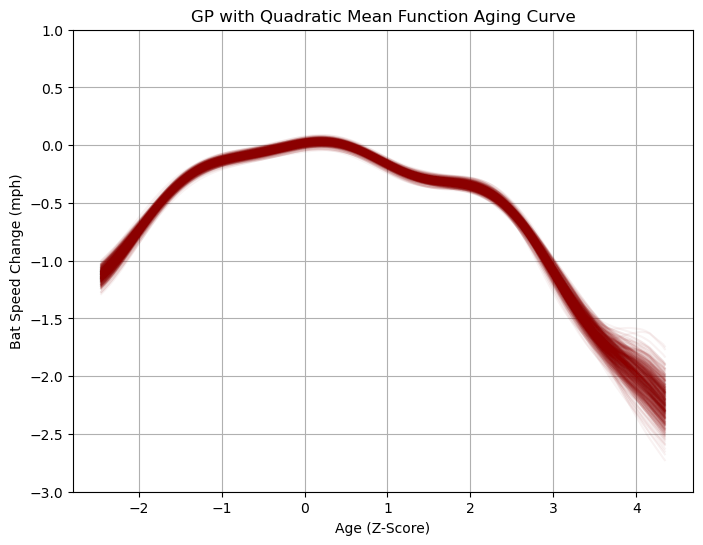

In [33]:
gp_aging_curve = plot_aging_curve(trace_gp_position, age_values, model_name="GP with Quadratic Mean Function")

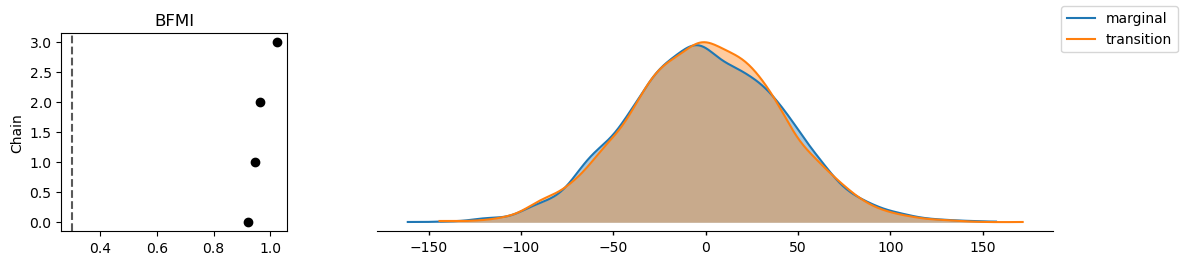

In [34]:
az.plot_energy(trace_gp_position)

In [35]:
spp = sample_posterior_pred(model_gp_position, trace_gp_position)

Sampling: [target]


Output()

Text(0.5, 0, 'Bat Speed (mph)')

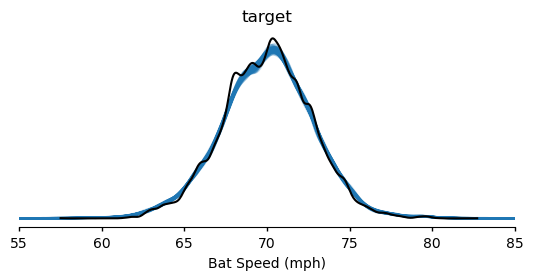

In [36]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

In [37]:
posit_means = trace_gp_position.posterior['position_effect'].mean(('chain','draw'))
sorted_coord = trace_gp_position.posterior['position'].sortby(posit_means)
posit_mean_sorted = trace_gp_position.sel(position=sorted_coord)

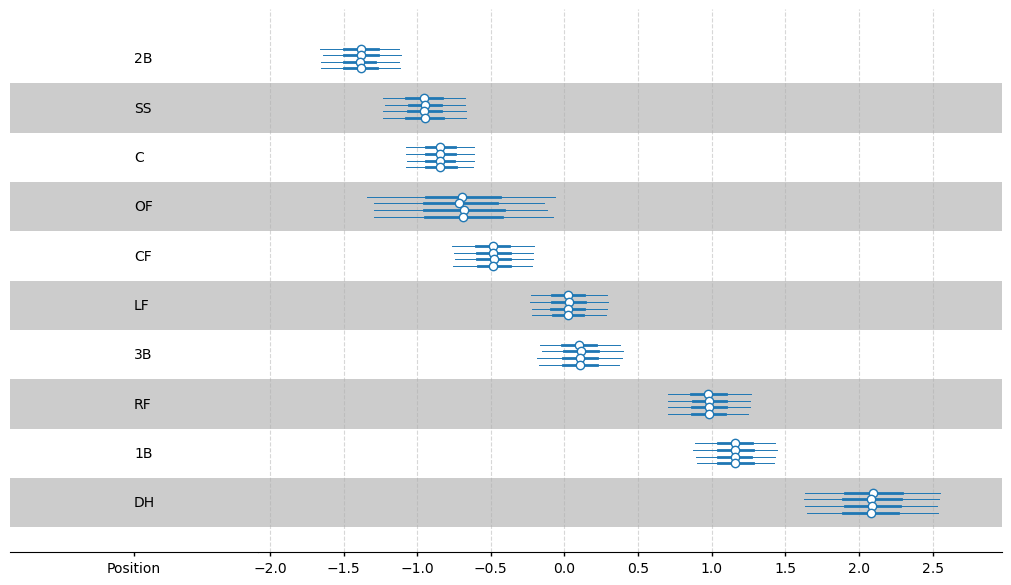

In [38]:
def rename_position(ds):
    if "position" in ds.dims:
        return ds.rename({"position": "Position"})
    return ds
posit_mean_sorted = posit_mean_sorted.map_over_datasets(rename_position)
pc = azp.plot_forest(
    posit_mean_sorted,
    var_names=['position_effect'],
    shade_label='Position',
    labels=['Position'],
    visuals={'remove_axis': True}
)
ax = plt.gca()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.show()